# PrO and Bayes for Lotka–Volterra data

We use the predator–prey experiment from Example 3 of [Chazal et al. (2026)](https://arxiv.org/abs/2509.10393). The same deterministic model is fitted to correctly specified data and to data generated with unmodelled process noise.

For a distribution $Q$ over parameters, PrO minimizes predictive score plus prior regularization,

$$J(Q)=\frac{\lambda_n}{n}\sum_{i=1}^n S(P_Q,y_i)+D_{\mathrm{KL}}(Q\,\|\,Q_0), \qquad P_Q=\int P_\theta\,dQ(\theta).$$

The particles follow the Wasserstein gradient flow of $J$. KGD monitors the residual gradient field without estimating the particle density,

$$\mathrm{KGD}^2(Q_N)=\frac{1}{N^2}\sum_{j,\ell=1}^N \mathcal T_{Q,\theta}\mathcal T_{Q,\theta'}K(\theta^{(j)},\theta^{(\ell)}).$$

See the [KGD demo](https://github.com/patrideo/pymc-prop-kgd-demo/blob/main/notebook.ipynb) for the derivation.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy.integrate import solve_ivp
from scipy.special import expit, logit, logsumexp

import pymc_prop as pro

# PyMC's ODE operation has no Numba lowering.
pytensor.config.linker = "cvm"
az.style.use("arviz-variat")

## Simulate predator–prey data

We infer $\theta_1=\operatorname{logit}(\alpha)$ and $\theta_2=\operatorname{logit}(\beta/\alpha)$. The remaining rates and initial populations are fixed, and $Q_0=\mathcal N(0,I_2)$.

In [2]:
TRUE_ALPHA, TRUE_BETA = expit([-1.0, -3.0])
TRUE_THETA = np.array([-1.0, logit(TRUE_BETA / TRUE_ALPHA)])
GAMMA, DELTA = 0.4, 0.02
INITIAL_STATE = np.array([10.0, 15.0])
OBSERVATION_SIGMA = 1.0
OBSERVATION_TIMES = np.arange(1.0, 61.0)
PREDICTION_TIMES = np.linspace(0.0, 80.0, 500)

SEEDS = {
    "process": 30, "measurement_well": 1201, "measurement_misspecified": 1202,
    "pro_well": 1301, "pro_misspecified": 1302,
    "predictive_bayes": 1401, "predictive_pro": 1402,
}

def lv_drift(state, theta):
    alpha = expit(theta[0])
    beta = alpha * expit(theta[1])
    prey, predator = state
    return np.array([
        alpha * prey - beta * prey * predator,
        DELTA * prey * predator - GAMMA * predator,
    ])

In [3]:
# The well-specified truth is the deterministic model used for fitting.
well_solution = solve_ivp(
    lambda t, state: lv_drift(state, TRUE_THETA),
    (0, PREDICTION_TIMES[-1]), INITIAL_STATE, t_eval=PREDICTION_TIMES,
)
latent_well = well_solution.y.T

# The misspecified truth adds Brownian process noise to both populations.
PROCESS_STEP = 0.05
PROCESS_NOISE = np.array([0.1, 0.2])
fine_times = np.arange(0, PREDICTION_TIMES[-1] + PROCESS_STEP, PROCESS_STEP)
latent_misspecified = np.empty((len(fine_times), 2))
latent_misspecified[0] = INITIAL_STATE
rng = np.random.default_rng(SEEDS["process"])

for i in range(len(fine_times) - 1):
    state = latent_misspecified[i]
    noise = PROCESS_NOISE * np.sqrt(PROCESS_STEP) * rng.normal(size=2)
    predictor = state + lv_drift(state, TRUE_THETA) * PROCESS_STEP + noise
    latent_misspecified[i + 1] = state + 0.5 * (
        lv_drift(state, TRUE_THETA) + lv_drift(predictor, TRUE_THETA)
    ) * PROCESS_STEP + noise

In [4]:
latent = {
    "well-specified": latent_well,
    "misspecified": latent_misspecified,
}
latent_times = {
    "well-specified": PREDICTION_TIMES,
    "misspecified": fine_times,
}

observed = {}
for name, seed in [("well-specified", SEEDS["measurement_well"]),
                   ("misspecified", SEEDS["measurement_misspecified"])]:
    values = np.column_stack([
        np.interp(OBSERVATION_TIMES, latent_times[name], latent[name][:, species])
        for species in range(2)
    ])
    observed[name] = values + np.random.default_rng(seed).normal(
        0, OBSERVATION_SIGMA, values.shape
    )

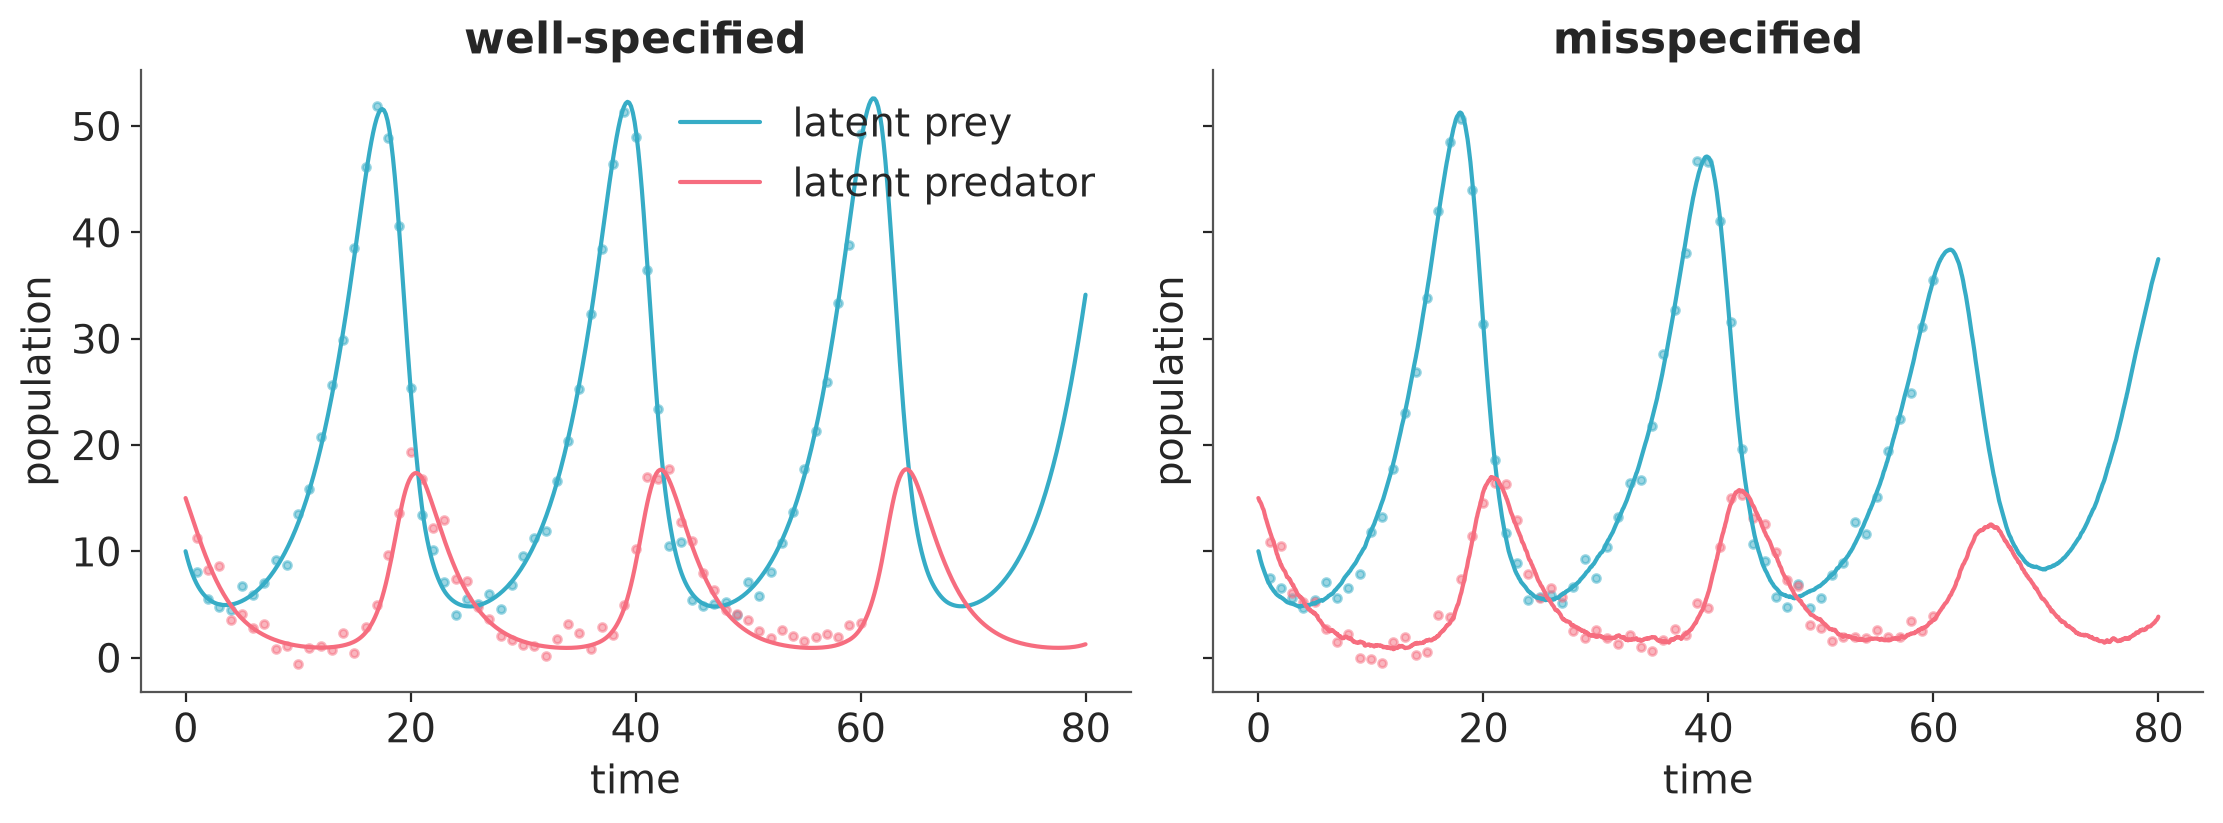

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, observed):
    ax.plot(latent_times[name], latent[name][:, 0], label="latent prey")
    ax.plot(latent_times[name], latent[name][:, 1], label="latent predator")
    ax.scatter(OBSERVATION_TIMES, observed[name][:, 0], s=8, alpha=.5)
    ax.scatter(OBSERVATION_TIMES, observed[name][:, 1], s=8, alpha=.5)
    ax.set(title=name, xlabel="time", ylabel="population")
axes[0].legend();

## PyMC model

Both datasets are fitted with the same deterministic ODE. The process noise is deliberately absent from the fitted model.

In [6]:
def pymc_lv_rhs(state, time, theta):
    alpha = pt.sigmoid(theta[0])
    beta = alpha * pt.sigmoid(theta[1])
    prey, predator = state
    return [
        alpha * prey - beta * prey * predator,
        DELTA * prey * predator - GAMMA * predator,
    ]

lv_ode = pm.ode.DifferentialEquation(
    pymc_lv_rhs, times=OBSERVATION_TIMES, n_states=2, n_theta=2, t0=0
)

def build_model(data):
    with pm.Model() as model:
        theta1 = pm.Normal("theta1", 0, 1)
        theta2 = pm.Normal("theta2", 0, 1)
        path = lv_ode(y0=INITIAL_STATE, theta=pt.stack((theta1, theta2)))
        pm.Normal("y", path, OBSERVATION_SIGMA, observed=data)
    return model

models = {name: build_model(data) for name, data in observed.items()}

## Development-only acceleration

The collapsed helper batches the ODE and forward-sensitivity solves. It evaluates the same Gaussian likelihood and log-score drift as `scoring_rule="log"`; only the numerical route differs. Remove this cell and the two development checks below before publication.

In [7]:
import diffrax
import jax
import jax.numpy as jnp
from pymc_prop.scoring import ScoringRule

jax.config.update("jax_enable_x64", True)

class LVForwardSensitivityLogScore(ScoringRule):
    """JIT-compiled, particle-batched LV log-score drift."""

    def __init__(self, data, *, log_ratio_clip=10.0, eps=1e-300):
        self.data = np.asarray(data, dtype=float)
        self.log_ratio_clip = log_ratio_clip
        self.eps = eps
        if self.data.shape != (len(OBSERVATION_TIMES), 2) or not np.isfinite(self.data).all():
            raise ValueError("data must be a finite observation array with two species")
        self._solve = self._compile_solver()

    def _compile_solver(self):
        observation_times = jnp.asarray(OBSERVATION_TIMES)
        initial_state = jnp.asarray(INITIAL_STATE)

        def solve_particle(theta):
            alpha = jax.nn.sigmoid(theta[0])
            beta_ratio = jax.nn.sigmoid(theta[1])
            beta = alpha * beta_ratio

            def augmented_rhs(_, augmented, __):
                prey, predator = augmented[:2]
                sensitivity = augmented[2:].reshape(2, 2)
                drift = jnp.array((
                    alpha * prey - beta * prey * predator,
                    DELTA * prey * predator - GAMMA * predator,
                ))
                state_jacobian = jnp.array((
                    (alpha - beta * predator, -beta * prey),
                    (DELTA * predator, DELTA * prey - GAMMA),
                ))
                alpha_derivative = alpha * (1 - alpha)
                beta_theta1_derivative = beta * (1 - alpha)
                beta_theta2_derivative = beta * (1 - beta_ratio)
                parameter_jacobian = jnp.array((
                    (alpha_derivative * prey - beta_theta1_derivative * prey * predator,
                     -beta_theta2_derivative * prey * predator),
                    (0.0, 0.0),
                ))
                sensitivity_drift = state_jacobian @ sensitivity + parameter_jacobian
                return jnp.concatenate((drift, sensitivity_drift.ravel()))

            initial = jnp.concatenate((initial_state, jnp.zeros(4)))
            return diffrax.diffeqsolve(
                diffrax.ODETerm(augmented_rhs), diffrax.Tsit5(),
                t0=0.0, t1=OBSERVATION_TIMES[-1], dt0=0.05, y0=initial,
                saveat=diffrax.SaveAt(ts=observation_times),
                stepsize_controller=diffrax.PIDController(rtol=2e-6, atol=2e-8),
                max_steps=4096,
            ).ys

        # vmap gives each particle its own adaptive solve; jit compiles the whole batch.
        return jax.jit(jax.vmap(solve_particle))

    def _logp_score(self, particles):
        particles = np.asarray(particles, dtype=float)
        if particles.ndim != 2 or particles.shape[1] != 2:
            raise ValueError("particles must have shape (n_particles, 2)")
        n_particles = len(particles)
        augmented = np.asarray(self._solve(jnp.asarray(particles)))
        mean = augmented[:, :, :2]
        sensitivity = augmented[:, :, 2:].reshape(n_particles, len(OBSERVATION_TIMES), 2, 2)
        residual = self.data[None, :, :] - mean
        variance = OBSERVATION_SIGMA ** 2
        # These are exactly the elementwise Normal log likelihood and its theta score.
        logp = (-0.5 * (residual ** 2 / variance + np.log(2 * np.pi * variance))).reshape(n_particles, -1)
        score = (residual[:, :, :, None] * sensitivity / variance).reshape(n_particles, -1, 2)
        return logp, score

    def compile_wgf(self, model, mapper):
        expected_names = tuple(item[0] for item in mapper.point_map_info)
        if expected_names != ("theta1", "theta2"):
            raise ValueError(f"expected theta1/theta2 particle order, got {expected_names}")

        def wgf(particles):
            logp, score = self._logp_score(particles)
            # Stable leave-one-particle-out mixture densities used by the log-score drift.
            shifted = np.exp(logp - logp.max(axis=0, keepdims=True))
            leave_one_out = np.maximum(shifted.sum(axis=0, keepdims=True) - shifted, self.eps)
            log_mix = logp.max(axis=0, keepdims=True) + np.log(leave_one_out) - np.log(len(particles) - 1)
            ratio = np.exp(np.clip(logp - log_mix, -self.log_ratio_clip, self.log_ratio_clip))
            return -np.sum(ratio[:, :, None] * score, axis=1)

        return wgf


In [8]:
# One-off check that the fast helper matches the standard PyMC score drift.
from pymc_prop.points import make_point_mapper
from pymc_prop.scoring import LogScore

parity_particles = np.random.default_rng(1).normal(TRUE_THETA, 0.05, size=(3, 2))
parity_mapper = make_point_mapper(models["well-specified"])
fast_drift = LVForwardSensitivityLogScore(observed["well-specified"]).compile_wgf(
    models["well-specified"], parity_mapper
)(parity_particles)
standard_drift = LogScore().compile_wgf(models["well-specified"], parity_mapper)(parity_particles)
np.testing.assert_allclose(fast_drift, standard_drift, rtol=2e-3, atol=2e-3)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: DifferentialEquation should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: DifferentialEquation should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


In [32]:
# Temporary warm start for diagnosing the particle flow; this does not change Q0.
from contextlib import contextmanager
import pymc_prop.sampler as pro_sampler

@contextmanager
def use_warm_start(sd):
    prior_initializer = pro_sampler.initialize_particles
    pro_sampler.initialize_particles = lambda model, mapper, n_particles, rng, **kwargs: (
        rng.normal(TRUE_THETA, sd, size=(n_particles, len(TRUE_THETA)))
    )
    try:
        yield
    finally:
        pro_sampler.initialize_particles = prior_initializer

## PrO sampling

The particle count controls the resolution of the empirical PrO distribution. The warm start and custom score are temporary development aids.

In [11]:
N_PARTICLES = 100
N_STEPS = 5000
WARM_START_SD = 1


pro_runs = {
    name: pro.sample_pro(
        model=model,
        scoring_rule=LVForwardSensitivityLogScore(observed[name]),
        n_particles=N_PARTICLES,
        n_steps=N_STEPS,
        tune=0,
        step_size=1e-8,
        r_eps=1e-9,
        kgd_interval=10,
        random_seed=SEEDS["pro_well" if name == "well-specified" else "pro_misspecified"],
        include_log_likelihood=False,
    )
    for name, model in models.items()
}

## KGD and FUSE diagnostics

KGD measures discrepancy from the PrO target; lower is better. FUSE adapts the integration step size during the particle flow.

KeyError: 'var names: "[\'fuse_half_step_distance_sq\' \'fuse_gradient_energy\' \'fuse_step_size\'] are not present" in dataset'

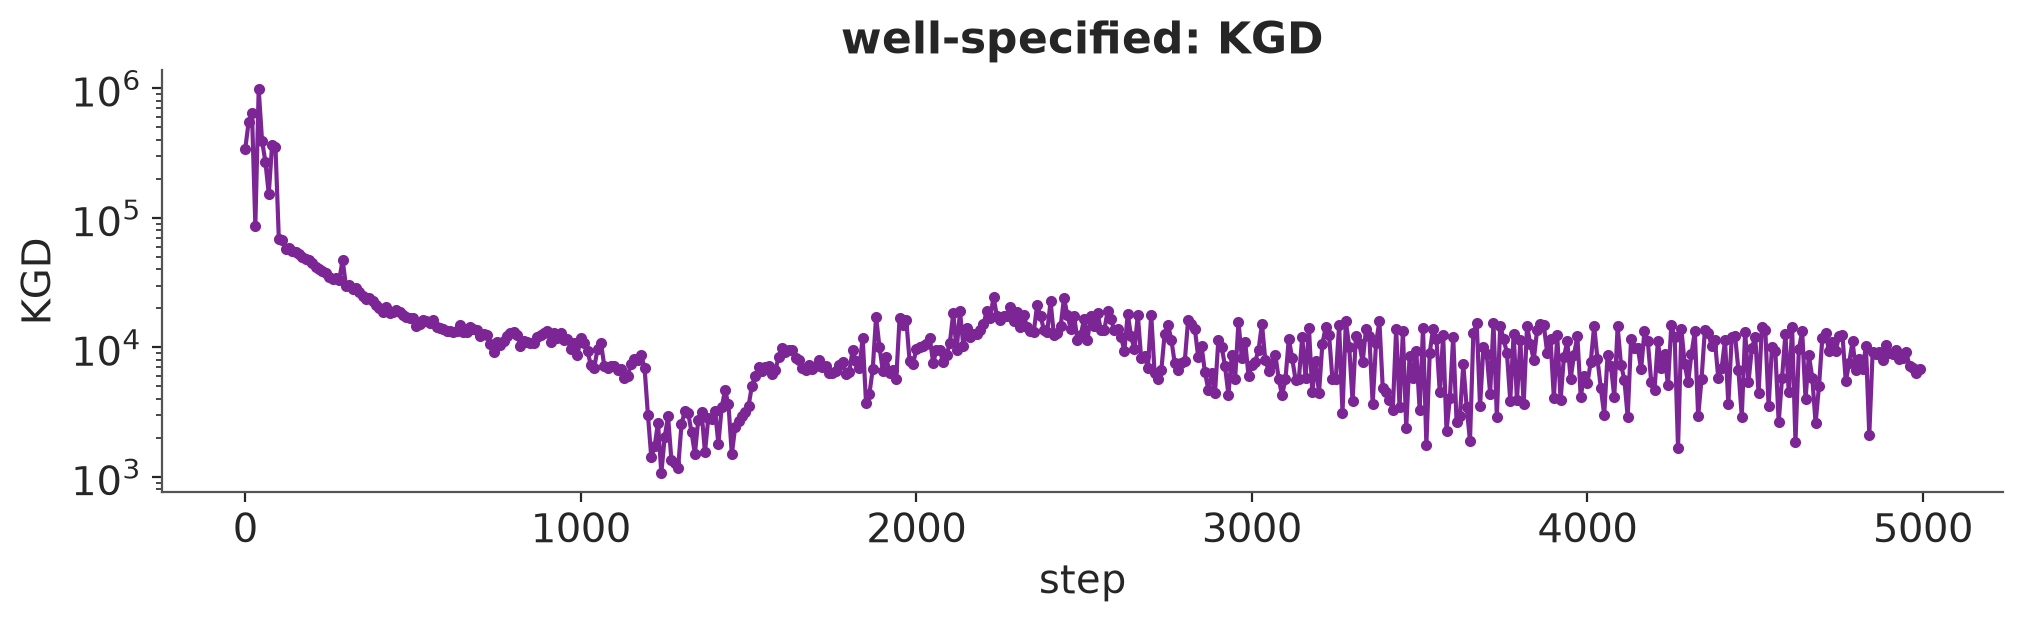

In [13]:
diagnostic_vars = [
    "fuse_half_step_distance_sq", "fuse_gradient_energy", "fuse_step_size"
]

for name, run in pro_runs.items():
    stats = run.sample_stats.isel(chain=0)
    kgd = stats["kgd"]
    finite = np.isfinite(kgd.values)

    _, ax = plt.subplots(figsize=(10, 3))
    ax.plot(
        kgd.step.values[finite],
        kgd.values[finite],
        color="C3",
        marker=".",
    )
    ax.set(
        title=f"{name}: KGD",
        xlabel="step",
        ylabel="KGD",
        yscale="log",
    )

    pc = az.plot_trace(
        run.sel(chain=[0]),
        var_names=diagnostic_vars,
        group="sample_stats",
        visuals={"trace": {"xname": "step"}},
        col_wrap=1,
        figure_kwargs={"figsize": (10, 9)},
    )
    pc.facet_map("set_yscale", scale="log")
    pc.add_title(f"{name}: FUSE diagnostics")

## Bayesian reference and particle movement

Because there are only two unknown parameters, a normalized grid provides a direct Bayesian reference.

In [14]:
def simulate_deterministic(theta, times):
    theta = np.atleast_2d(theta)
    alpha = expit(theta[:, 0])
    beta = alpha * expit(theta[:, 1])

    def rhs(t, flat_state):
        state = flat_state.reshape(len(theta), 2)
        prey, predator = state.T
        return np.column_stack([
            alpha * prey - beta * prey * predator,
            DELTA * prey * predator - GAMMA * predator,
        ]).ravel()

    solution = solve_ivp(
        rhs, (0, times[-1]), np.tile(INITIAL_STATE, len(theta)),
        t_eval=times, rtol=2e-6, atol=2e-8,
    )
    return solution.y.T.reshape(len(times), len(theta), 2).transpose(1, 0, 2)

def grid_reference(data, grid_size=121):
    theta1 = np.linspace(-2, 0, grid_size)
    theta2 = np.linspace(-2.5, -0.5, grid_size)
    mesh1, mesh2 = np.meshgrid(theta1, theta2, indexing="ij")
    points = np.column_stack([mesh1.ravel(), mesh2.ravel()])
    paths = simulate_deterministic(points, OBSERVATION_TIMES)
    log_posterior = -0.5 * np.sum(
        ((data - paths) / OBSERVATION_SIGMA) ** 2, axis=(1, 2)
    ) - 0.5 * np.sum(points ** 2, axis=1)
    weights = np.exp(log_posterior - logsumexp(log_posterior))
    return theta1, theta2, points, weights

bayes = {name: grid_reference(data) for name, data in observed.items()}

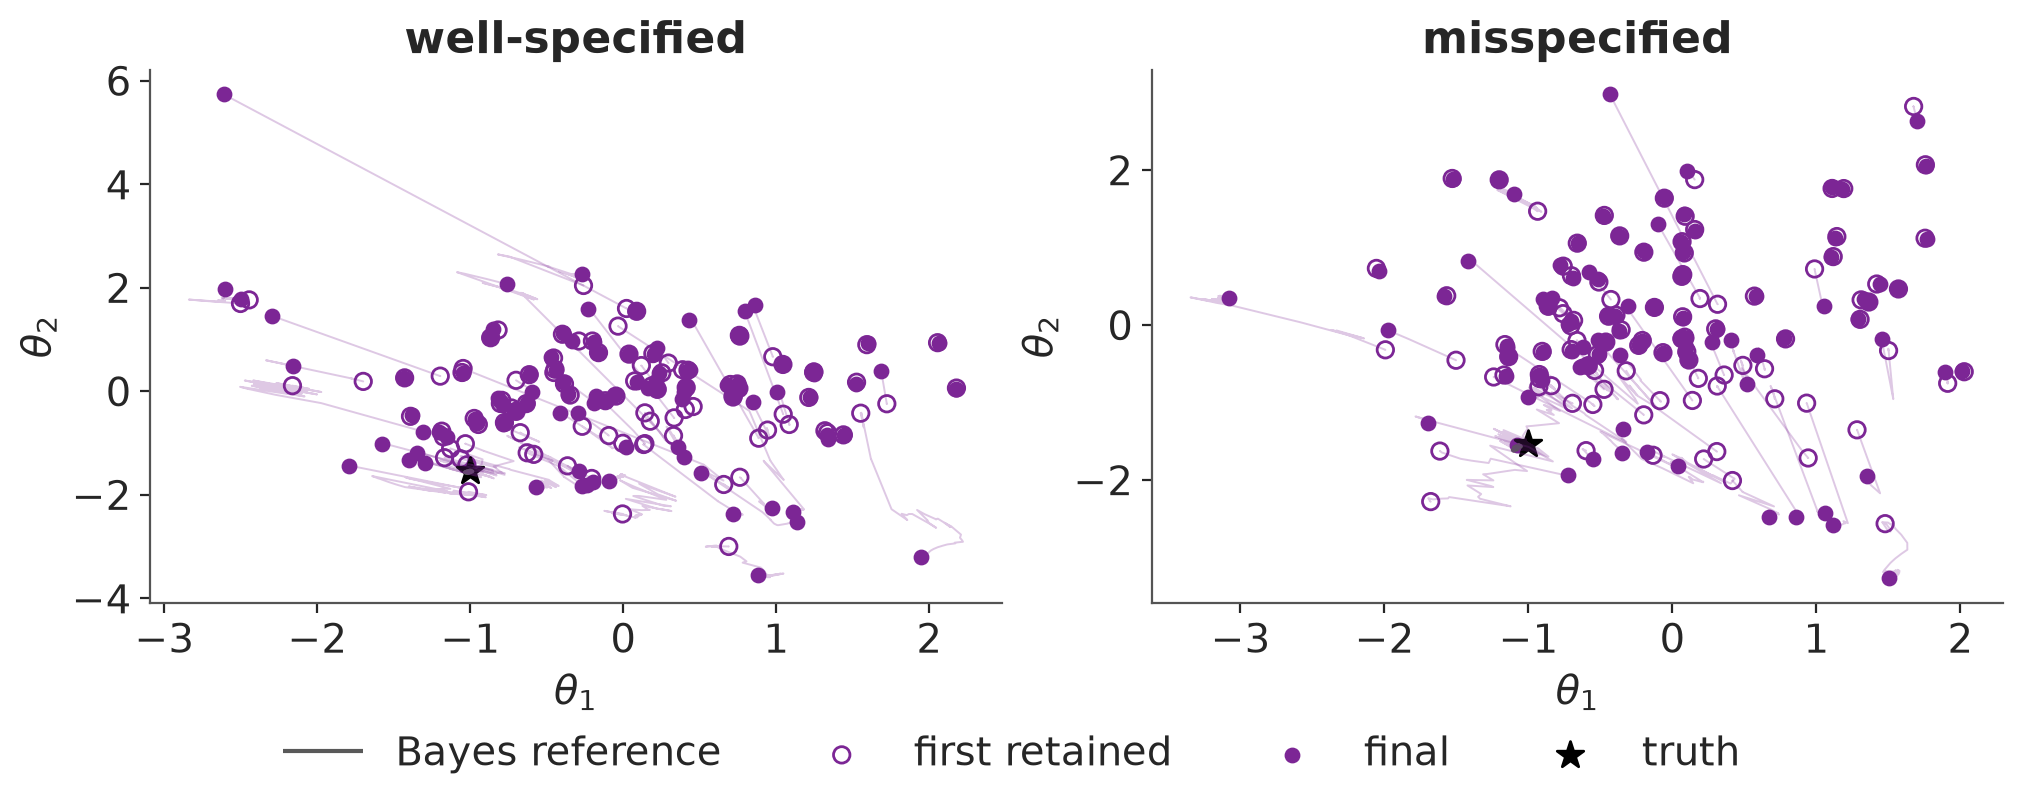

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, name in zip(axes, observed):
    theta1, theta2, _, weights = bayes[name]
    density = weights.reshape(len(theta1), len(theta2))
    contours = ax.contour(
        theta1, theta2, density.T,
        levels=np.array([.05, .25, .5, .8]) * density.max(), colors="0.35",
    )

    particles = pro_runs[name].posterior
    for chain in particles.chain.values:
        ax.plot(
            particles.theta1.sel(chain=chain),
            particles.theta2.sel(chain=chain),
            color="C3", alpha=.25, linewidth=.7,
        )

    initial = particles.isel(draw=0)
    final = particles.isel(draw=-1)
    ax.scatter(initial.theta1, initial.theta2, facecolors="none",
               edgecolors="C3", s=35, label="first retained")
    ax.scatter(final.theta1, final.theta2, color="C3",
               s=22, label="final")
    ax.scatter(*TRUE_THETA, marker="*", color="black", s=100, label="truth")
    ax.set(title=name, xlabel=r"$\theta_1$", ylabel=r"$\theta_2$")

bayes_handle = contours.legend_elements()[0][0]
handles, labels = axes[0].get_legend_handles_labels()
fig.legend([bayes_handle, *handles], ["Bayes reference", *labels],
           loc="outside lower center", ncols=4, frameon=False);

## Posterior predictive comparison

Bands show predictive interquartile ranges including fresh measurement noise. The colored PrO line is the arithmetic mean of the deterministic trajectory represented by each final particle.

In [18]:
N_PREDICTIVE_DRAWS = 1_000
prediction_ode = pm.ode.DifferentialEquation(
    pymc_lv_rhs, times=PREDICTION_TIMES[1:], n_states=2, n_theta=2, t0=0
)

with pm.Model(coords={
    "predictive_draw": np.arange(N_PREDICTIVE_DRAWS),
    "time": PREDICTION_TIMES,
    "species": ["prey", "predator"],
}) as prediction_model:
    theta1 = pm.Normal("theta1", 0, 1)
    theta2 = pm.Normal("theta2", 0, 1)
    path = prediction_ode(y0=INITIAL_STATE, theta=pt.stack((theta1, theta2)))
    path = pt.concatenate([pt.as_tensor(INITIAL_STATE)[None, :], path], axis=0)
    pm.Normal("y", path[None, :, :], OBSERVATION_SIGMA,
              dims=("predictive_draw", "time", "species"))

In [19]:
predictive = {}
predictive_mean = {}

for scenario, name in enumerate(observed):
    _, _, grid, weights = bayes[name]
    rng = np.random.default_rng(SEEDS["predictive_bayes"] + scenario)
    bayes_theta = grid[rng.choice(len(grid), N_PREDICTIVE_DRAWS, p=weights)]
    bayes_paths = simulate_deterministic(bayes_theta, PREDICTION_TIMES)
    bayes_draws = bayes_paths + rng.normal(0, OBSERVATION_SIGMA, bayes_paths.shape)

    final = pro_runs[name].isel(draw=slice(-1, None), missing_dims="ignore")
    pro_forward = pro.sample_posterior_predictive_pro(
        final, model=prediction_model, predictions=True, var_names=["y"],
        random_seed=SEEDS["predictive_pro"] + scenario, extend_inferencedata=False,
    )
    pro_draws = pro_forward.predictions["y"].isel(draw=0).values
    pro_theta = np.column_stack([
        final.posterior.theta1.values.ravel(), final.posterior.theta2.values.ravel()
    ])

    predictive[name] = {"Bayes": bayes_draws, "PrO": pro_draws}
    predictive_mean[name] = {
        "Bayes": bayes_paths.mean(axis=0),
        "PrO": simulate_deterministic(pro_theta, PREDICTION_TIMES).mean(axis=0),
    }

Sampling: [y]
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/arviz_base/base.py:131: UserWarning: Found chain dimension to be longer than draw dimension, check dimensions are correctly named.
  warnings.warn(
Sampling: [y]
/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/arviz_base/base.py:131: UserWarning: Found chain dimension to be longer than draw dimension, check dimensions are correctly named.
  warnings.warn(


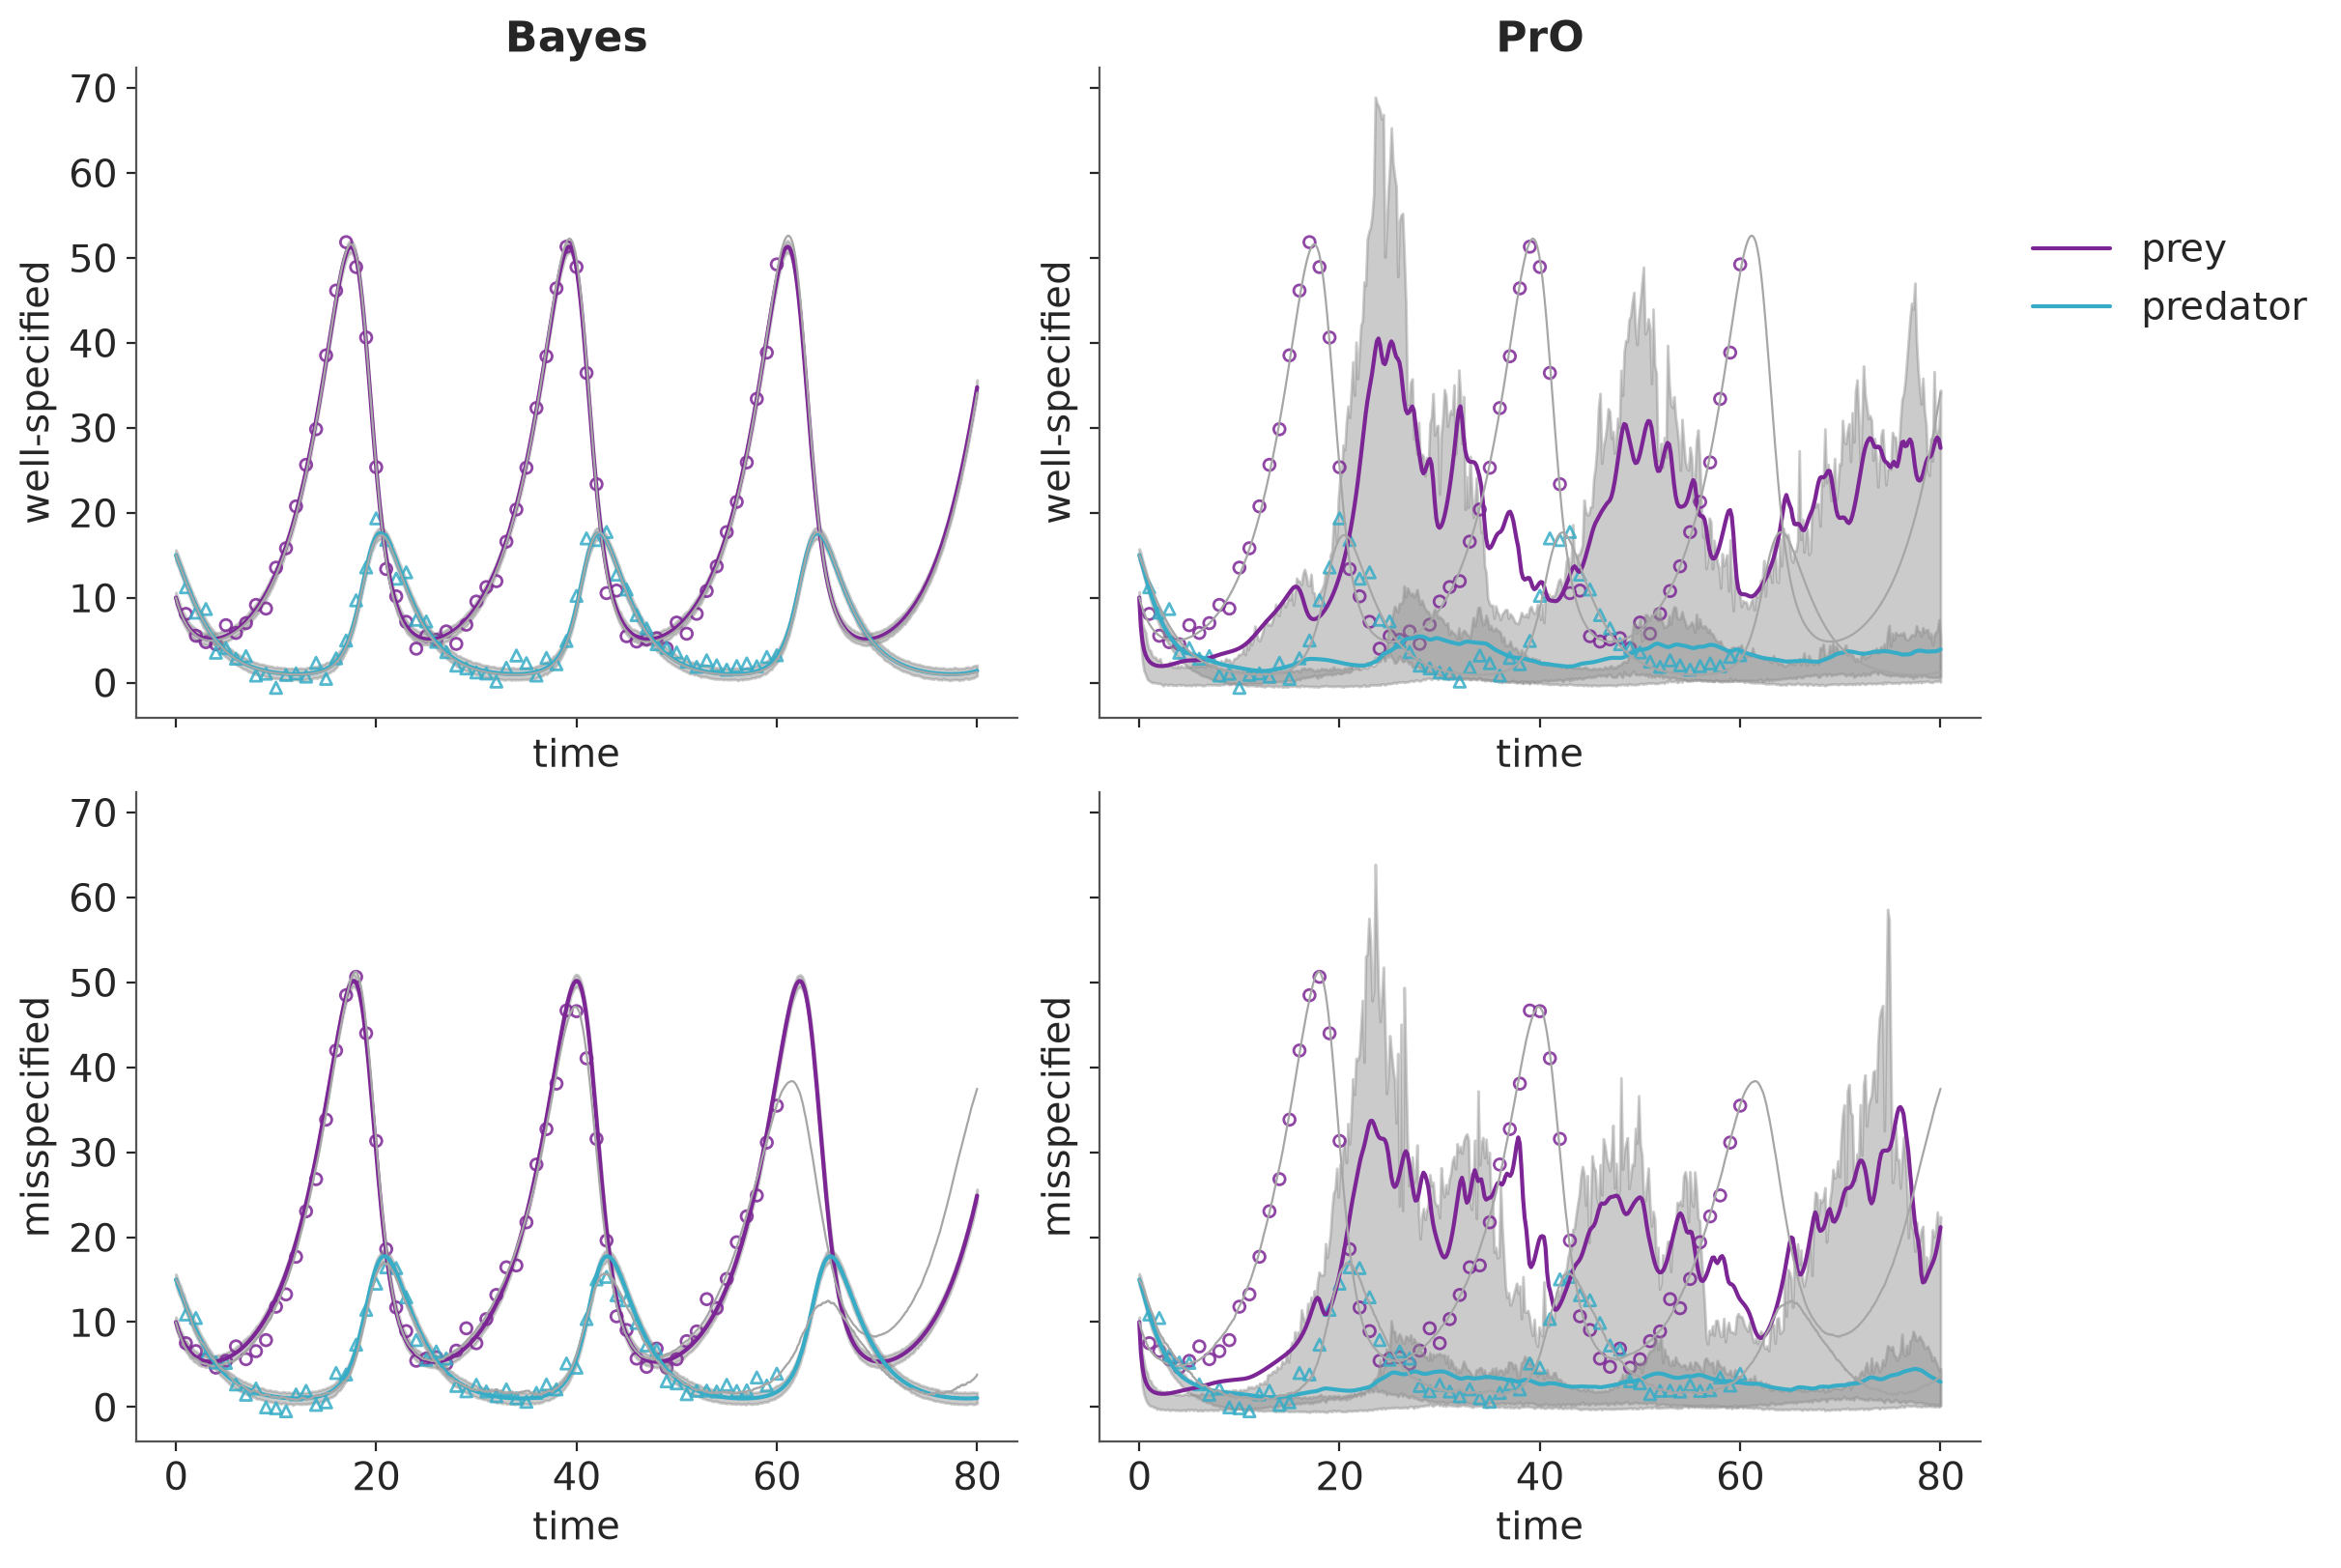

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True,
                         layout="constrained")
colors = ["C3", "C0"]
labels = ["prey", "predator"]
markers = ["o", "^"]

for row, name in enumerate(observed):
    for col, method in enumerate(["Bayes", "PrO"]):
        ax = axes[row, col]
        for species in range(2):
            lower, upper = np.quantile(
                predictive[name][method][:, :, species], [.25, .75], axis=0
            )
            ax.fill_between(PREDICTION_TIMES, lower, upper, color="0.55", alpha=.45)
            ax.plot(PREDICTION_TIMES, predictive_mean[name][method][:, species],
                    color=colors[species], label=labels[species])
            ax.plot(latent_times[name], latent[name][:, species], color="0.65", linewidth=.8)
            ax.scatter(OBSERVATION_TIMES, observed[name][:, species],
                       facecolors="none", edgecolors=colors[species],
                       marker=markers[species], s=18, alpha=.85)
        ax.set(title=method if row == 0 else None, xlabel="time", ylabel=name)

axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.02, .8));

Under misspecification, parameter recovery is not the relevant criterion: both methods approximate a stochastic process with deterministic trajectories. Predictive fit and spread are therefore more informative than proximity to the generating drift.